In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KDTree
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import friedmanchisquare, wilcoxon
import anndata


In [2]:

root_path = Path("/mnt/jwh83-data/Confetti")
output_dir = root_path / "output"

# HubMAP (ground truth)
HUBMAP_H5AD = output_dir / "HuBMAP_Yang_annotate.h5ad"

# Model outputs (Nature intentionally ignored)
MODEL_H5ADS = {
    "Mesmer":      output_dir / "Channel_feature" / "Merged" / "mesmer_leiden_prelim.h5ad",
    "Cellpose":    output_dir / "Channel_feature" / "Merged" / "cellpose_old_update3_leiden_prelim.h5ad",
    "CellposeSAM": output_dir / "Channel_feature" / "Merged" / "cellposeSAM_leiden_prelim.h5ad",
    "MicroSAM":    output_dir / "Channel_feature" / "Merged" / "microSAM_leiden_prelim.h5ad",
    "CellSAM":     output_dir / "Channel_feature" / "Merged" / "cellSAM_2_update_leiden_prelim.h5ad",
    "InstanSeg":   output_dir / "Channel_feature" / "Merged" / "instanseg_leiden_prelim.h5ad",
}

In [3]:
root_path = Path("/mnt/jwh83-data/Confetti")
output_dir = root_path / "output"

HUBMAP_H5AD = output_dir / "HuBMAP_Yang_annotate.h5ad"

MODEL_H5ADS = {
    "Mesmer":      output_dir / "Channel_feature" / "Merged" / "mesmer_leiden_prelim.h5ad",
    "Cellpose":    output_dir / "Channel_feature" / "Merged" / "cellpose_old_update3_leiden_prelim.h5ad",
    "CellposeSAM": output_dir / "Channel_feature" / "Merged" / "cellposeSAM_leiden_prelim.h5ad",
    "MicroSAM":    output_dir / "Channel_feature" / "Merged" / "microSAM_leiden_prelim.h5ad",
    "CellSAM":     output_dir / "Channel_feature" / "Merged" / "cellSAM_2_update_leiden_prelim.h5ad",
    "InstanSeg":   output_dir / "Channel_feature" / "Merged" / "instanseg_leiden_prelim.h5ad",
}

In [4]:
REGION_COL = "sample_ID"
X_COL = "x"
Y_COL = "y"

MAX_DIST = 5.0
ENFORCE_MUTUAL = False

# Metrics to summarize (higher is better except cellcount_absdiff)
SUMMARY_METRICS = ["f1_weighted", "f1_macro", "purity", "ari", "nmi", "cellcount_absdiff", "match_rate_method"]


In [5]:
def pick_first_existing(columns, candidates, required=True, name="column"):
    for c in candidates:
        if c in columns:
            return c
    if required:
        raise KeyError(f"Could not find {name}. Tried: {candidates}")
    return None

def ensure_required_obs(adata, required_cols):
    missing = [c for c in required_cols if c not in adata.obs.columns]
    if missing:
        raise KeyError(f"Missing required .obs columns: {missing}")

def detect_label_col(adata, prefer=("prelim_cell_type_mapped", "prelim_cell_type", "cell_type_update", "cell_type", "Cell Type")):
    return pick_first_existing(adata.obs.columns, list(prefer), required=True, name="label column")

def detect_cluster_col(adata, prefer_prefix=("leiden",), fallbacks=("cluster", "clusters")):
    cols = list(adata.obs.columns)
    for p in prefer_prefix:
        hits = [c for c in cols if str(c).startswith(p)]
        if hits:
            hits_sorted = sorted(hits, key=lambda s: (len(s), s))
            return hits_sorted[0]
    for f in fallbacks:
        hits = [c for c in cols if f in str(c).lower()]
        if hits:
            hits_sorted = sorted(hits, key=lambda s: (len(s), s))
            return hits_sorted[0]
    raise KeyError("Could not detect a clustering column (expected something like 'leiden').")



In [6]:
adata_hub = anndata.read_h5ad(HUBMAP_H5AD)
ensure_required_obs(adata_hub, [REGION_COL, X_COL, Y_COL])
hub_label_col = detect_label_col(adata_hub)

model_adatas = {}
model_cluster_cols = {}

for name, fp in MODEL_H5ADS.items():
    ad = anndata.read_h5ad(fp)
    ensure_required_obs(ad, [REGION_COL, X_COL, Y_COL])
    model_adatas[name] = ad
    model_cluster_cols[name] = detect_cluster_col(ad)

print("HubMAP label column:", hub_label_col)
print("Detected clustering columns:", model_cluster_cols)

/home/labuser/anaconda3/envs/rapids-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


HubMAP label column: prelim_cell_type
Detected clustering columns: {'Mesmer': 'leiden', 'Cellpose': 'leiden', 'CellposeSAM': 'leiden', 'MicroSAM': 'leiden', 'CellSAM': 'leiden', 'InstanSeg': 'leiden'}


In [7]:
def nn_match_per_region(adata_A, adata_B, region,
                        region_col=REGION_COL,
                        xA=X_COL, yA=Y_COL,
                        xB=X_COL, yB=Y_COL,
                        max_dist=MAX_DIST,
                        enforce_mutual=ENFORCE_MUTUAL):
    obsA, obsB = adata_A.obs, adata_B.obs

    mA = (obsA[region_col].astype(str) == str(region))
    mB = (obsB[region_col].astype(str) == str(region))
    if not mA.any() or not mB.any():
        return pd.DataFrame(columns=["idx_A", "idx_B", "dist", "region"])

    A_inds = obsA.index[mA]
    B_inds = obsB.index[mB]

    A_xy = obsA.loc[A_inds, [xA, yA]].to_numpy(dtype=float)
    B_xy = obsB.loc[B_inds, [xB, yB]].to_numpy(dtype=float)

    # Drop NaNs
    A_ok = ~np.isnan(A_xy).any(axis=1)
    B_ok = ~np.isnan(B_xy).any(axis=1)
    A_inds = A_inds[A_ok]
    B_inds = B_inds[B_ok]
    A_xy = A_xy[A_ok]
    B_xy = B_xy[B_ok]

    if len(A_xy) == 0 or len(B_xy) == 0:
        return pd.DataFrame(columns=["idx_A", "idx_B", "dist", "region"])

    tree_B = KDTree(B_xy)
    dAB, nnAB = tree_B.query(A_xy, k=1)
    dAB = dAB.ravel()
    nnAB = nnAB.ravel()

    keep = dAB <= max_dist
    if keep.sum() == 0:
        return pd.DataFrame(columns=["idx_A", "idx_B", "dist", "region"])

    matched = pd.DataFrame({
        "idx_A": A_inds[keep].to_numpy(),
        "idx_B": B_inds[nnAB[keep]].to_numpy(),
        "dist": dAB[keep],
        "region": str(region),
    })

    if enforce_mutual:
        tree_A = KDTree(A_xy)
        dBA, nnBA = tree_A.query(B_xy, k=1)
        dBA = dBA.ravel()
        nnBA = nnBA.ravel()

        A_pos = pd.Series(np.arange(len(A_inds)), index=A_inds)
        B_pos = pd.Series(np.arange(len(B_inds)), index=B_inds)

        apos = A_pos.loc[matched["idx_A"]].to_numpy()
        bpos = B_pos.loc[matched["idx_B"]].to_numpy()

        is_mutual = (nnBA[bpos] == apos) & (matched["dist"].to_numpy() <= max_dist)
        matched = matched.loc[is_mutual].reset_index(drop=True)

    return matched

In [8]:
def purity_score(cluster_labels, gt_labels):
    df = pd.DataFrame({"c": cluster_labels, "g": gt_labels}).dropna()
    if df.empty:
        return np.nan
    ct = pd.crosstab(df["c"], df["g"])
    denom = ct.values.sum()
    return (ct.max(axis=1).sum() / denom) if denom > 0 else np.nan

def cluster_level_f1(cluster_labels, gt_labels, average="macro"):
    """
    Cluster-level F1 (your sense):
      - For each cluster: majority HubMAP label = predicted label for that cluster
      - Compute F1 for that label based on cluster membership (tp/fp/fn)
      - Average across clusters: macro or weighted by cluster size
    """
    df = pd.DataFrame({"c": cluster_labels, "g": gt_labels}).dropna()
    if df.empty:
        return np.nan

    gt_totals = df["g"].value_counts()

    f1s = []
    weights = []

    for c, sub in df.groupby("c"):
        maj = sub["g"].value_counts().idxmax()
        tp = int((sub["g"] == maj).sum())
        fp = int((sub["g"] != maj).sum())
        fn = int(gt_totals.get(maj, 0) - tp)
        denom = (2 * tp + fp + fn)
        f1 = (2 * tp / denom) if denom > 0 else np.nan

        f1s.append(f1)
        weights.append(len(sub))

    f1s = np.array(f1s, dtype=float)
    weights = np.array(weights, dtype=float)

    if average == "macro":
        return np.nanmean(f1s)
    if average == "weighted":
        ok = ~np.isnan(f1s)
        return (np.sum(f1s[ok] * weights[ok]) / np.sum(weights[ok])) if ok.any() else np.nan
    raise ValueError("average must be 'macro' or 'weighted'")



In [9]:
def compute_method_metrics_vs_hubmap(method_name, adata_method):
    cluster_col = model_cluster_cols[method_name]

    regions = sorted(set(adata_method.obs[REGION_COL].dropna().astype(str)).intersection(
                     set(adata_hub.obs[REGION_COL].dropna().astype(str))))

    rows = []
    all_dists = []

    for r in regions:
        matches = nn_match_per_region(adata_method, adata_hub, r)

        n_method_region = int((adata_method.obs[REGION_COL].astype(str) == r).sum())
        n_hub_region = int((adata_hub.obs[REGION_COL].astype(str) == r).sum())

        if len(matches) == 0:
            rows.append({
                "method": method_name,
                "region": r,
                "n_matched": 0,
                "match_rate_method": 0.0,
                "match_rate_hubmap": 0.0,
                "cellcount_method": n_method_region,
                "cellcount_hubmap": n_hub_region,
                "cellcount_diff": n_method_region - n_hub_region,
                "cellcount_absdiff": abs(n_method_region - n_hub_region),
                "purity": np.nan,
                "ari": np.nan,
                "nmi": np.nan,
                "f1_macro": np.nan,
                "f1_weighted": np.nan,
            })
            continue

        all_dists.append(matches["dist"].to_numpy())

        clusters = adata_method.obs.loc[matches["idx_A"], cluster_col].astype(str).to_numpy()
        gt = adata_hub.obs.loc[matches["idx_B"], hub_label_col].astype(str).to_numpy()

        purity = purity_score(clusters, gt)

        c_codes, _ = pd.factorize(clusters)
        g_codes, _ = pd.factorize(gt)
        ari = adjusted_rand_score(g_codes, c_codes)
        nmi = normalized_mutual_info_score(g_codes, c_codes)

        f1m = cluster_level_f1(clusters, gt, average="macro")
        f1w = cluster_level_f1(clusters, gt, average="weighted")

        n_matched = len(matches)

        rows.append({
            "method": method_name,
            "region": r,
            "n_matched": n_matched,
            "match_rate_method": n_matched / n_method_region if n_method_region > 0 else np.nan,
            "match_rate_hubmap": n_matched / n_hub_region if n_hub_region > 0 else np.nan,
            "cellcount_method": n_method_region,
            "cellcount_hubmap": n_hub_region,
            "cellcount_diff": n_method_region - n_hub_region,
            "cellcount_absdiff": abs(n_method_region - n_hub_region),
            "purity": purity,
            "ari": ari,
            "nmi": nmi,
            "f1_macro": f1m,
            "f1_weighted": f1w,
        })

    dist_vec = np.concatenate(all_dists) if len(all_dists) else np.array([])
    return pd.DataFrame(rows), dist_vec


all_metrics = []
dist_by_method = {}

for name, ad in model_adatas.items():
    dfm, dists = compute_method_metrics_vs_hubmap(name, ad)
    all_metrics.append(dfm)
    dist_by_method[name] = dists

metrics_df = pd.concat(all_metrics, ignore_index=True)


In [10]:
def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)

    prev = 0.0
    for rank, idx in enumerate(order):
        factor = (m - rank)
        val = pvals[idx] * factor
        val = max(val, prev)
        prev = val
        adj[idx] = min(val, 1.0)
    return adj

def friedman_and_posthoc(df, metric):
    pivot = df.pivot_table(index="region", columns="method", values=metric, aggfunc="mean")
    pivot = pivot.dropna(axis=0, how="any")  # complete-case regions only

    if pivot.shape[0] < 3 or pivot.shape[1] < 2:
        return None, None, None

    methods = list(pivot.columns)
    arrays = [pivot[m].to_numpy() for m in methods]
    chi2, p = friedmanchisquare(*arrays)

    # posthoc paired Wilcoxon + Holm
    pairs = []
    pvals = []
    med_diffs = []

    for i in range(len(methods)):
        for j in range(i + 1, len(methods)):
            A = methods[i]
            B = methods[j]
            a = pivot[A].to_numpy()
            b = pivot[B].to_numpy()

            if np.allclose(a, b, equal_nan=False):
                w_p = 1.0
            else:
                try:
                    _, w_p = wilcoxon(a, b, zero_method="wilcox", alternative="two-sided")
                except ValueError:
                    w_p = np.nan

            pairs.append((A, B))
            pvals.append(w_p)
            med_diffs.append(float(np.nanmedian(a - b)))

    p_adj = holm_adjust(pvals)

    posthoc = pd.DataFrame({
        "metric": metric,
        "A": [a for a, b in pairs],
        "B": [b for a, b in pairs],
        "median_diff(A-B)": med_diffs,
        "p_value": pvals,
        "p_adj_holm": p_adj,
        "reject_0.05": (p_adj < 0.05),
    }).sort_values("p_adj_holm")

    friedman_res = {"metric": metric, "n_regions": int(pivot.shape[0]), "chi2": float(chi2), "p": float(p)}
    return friedman_res, posthoc, pivot

friedman_results = []
posthoc_tables = {}

for metric in ["f1_weighted", "purity", "ari", "nmi", "cellcount_absdiff", "match_rate_method"]:
    fr, ph, pv = friedman_and_posthoc(metrics_df, metric)
    if fr is not None:
        friedman_results.append(fr)
        posthoc_tables[metric] = ph

friedman_df = pd.DataFrame(friedman_results).sort_values("p") if friedman_results else pd.DataFrame()



,rank,method,n_regions,f1_weighted_median,f1_weighted_iqr,purity_median,purity_iqr,ari_median,ari_iqr,nmi_median,nmi_iqr,match_rate_method_median,match_rate_method_iqr,cellcount_absdiff_median,cellcount_absdiff_iqr,composite_score
0,1,CellposeSAM,8,0.499846,0.042516,0.633232,0.044862,0.354670,0.074785,0.532585,0.047745,0.602261,0.044907,1206.5,1114.75,0.958480
1,2,Mesmer,8,0.491194,0.046826,0.611347,0.075061,0.362926,0.098844,0.522960,0.044939,0.661653,0.035993,1507.0,1059.50,0.331834
2,3,CellSAM,8,0.498135,0.036686,0.634547,0.075394,0.370898,0.089000,0.537554,0.047396,0.659252,0.035678,1829.0,1710.50,-0.242474
3,4,InstanSeg,8,0.526571,0.073796,0.653347,0.054364,0.383995,0.087886,0.539911,0.059350,0.558843,0.062941,2539.0,4251.25,-1.584894
4,5,Cellpose,8,0.528684,0.025429,0.636411,0.052566,0.393613,0.059925,0.547749,0.043435,0.622216,0.045455,3227.0,2016.75,-2.934736
5,6,MicroSAM,8,0.522572,0.035907,0.643335,0.059801,0.391855,0.074384,0.541222,0.047243,0.547233,0.054372,4078.0,2396.50,-4.687200


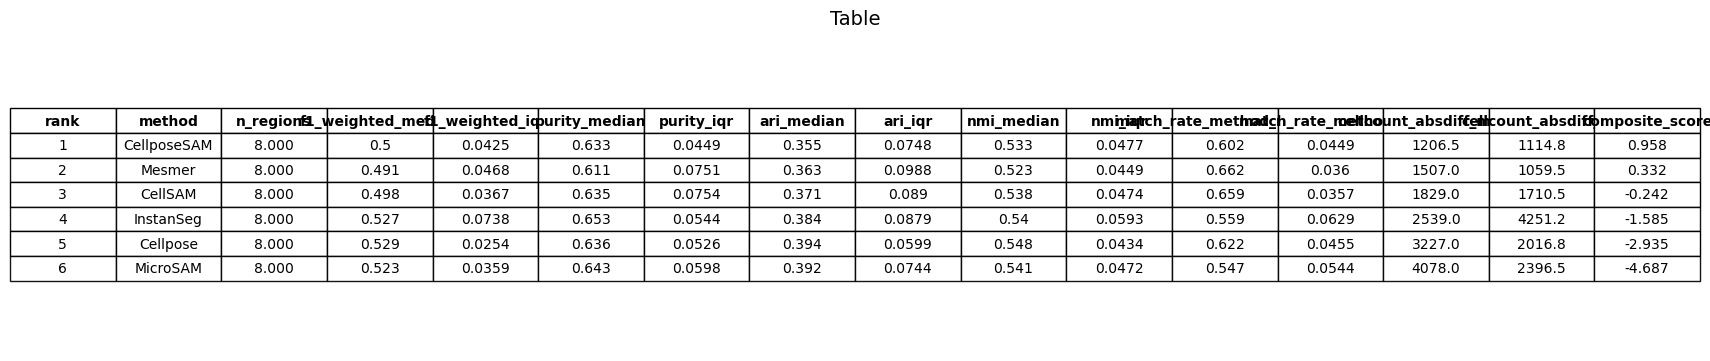

In [11]:
def summarize_methods(metrics_df):
    out = []
    for method, sub in metrics_df.groupby("method"):
        row = {"method": method, "n_regions": int(sub["region"].nunique())}

        # robust summaries
        for m in SUMMARY_METRICS:
            if m not in sub.columns:
                continue
            row[f"{m}_median"] = float(np.nanmedian(sub[m].to_numpy()))
            row[f"{m}_iqr"] = float(np.nanpercentile(sub[m].to_numpy(), 75) - np.nanpercentile(sub[m].to_numpy(), 25))

        out.append(row)

    summ = pd.DataFrame(out)

    # rank: prefer high f1_weighted median; tie-break with purity/ari; penalize abs count diff
    # (Feel free to adjust weights)
    def safe(col):
        return summ[col].fillna(summ[col].median()) if col in summ.columns else 0.0

    score = (
        3.0 * safe("f1_weighted_median") +
        1.5 * safe("purity_median") +
        1.0 * safe("ari_median") +
        0.5 * safe("nmi_median") +
        0.5 * safe("match_rate_method_median") -
        0.002 * safe("cellcount_absdiff_median")
    )
    summ["composite_score"] = score.astype(float)

    # sort best-to-worst by score
    summ = summ.sort_values("composite_score", ascending=False).reset_index(drop=True)
    summ["rank"] = np.arange(1, len(summ) + 1)

    # nicer ordering of columns
    keep_cols = [
        "rank", "method", "n_regions",
        "f1_weighted_median", "f1_weighted_iqr",
        "purity_median", "purity_iqr",
        "ari_median", "ari_iqr",
        "nmi_median", "nmi_iqr",
        "match_rate_method_median", "match_rate_method_iqr",
        "cellcount_absdiff_median", "cellcount_absdiff_iqr",
        "composite_score",
    ]
    keep_cols = [c for c in keep_cols if c in summ.columns]
    return summ[keep_cols]

summary_df = summarize_methods(metrics_df)

# Display a clean dataframe (not just print)
display(summary_df)

# Render as a clean TABLE FIGURE (visual)
def render_table_figure(df, title="Table"):
    """
    Render a DataFrame as a clean matplotlib table.
    Robust to mixed types (numbers + strings).
    """
    df_show = df.copy()

    def fmt(x):
        if pd.isna(x):
            return ""
        # leave strings as-is
        if isinstance(x, str):
            return x
        # try numeric formatting
        try:
            xv = float(x)
        except Exception:
            return str(x)
        # numeric formatting rules
        if abs(xv) >= 1000:
            return f"{xv:.1f}"
        if abs(xv) >= 1:
            return f"{xv:.3f}"
        # small numbers -> scientific (nice for p-values)
        return f"{xv:.3g}"

    # format each cell
    for c in df_show.columns:
        # keep common ID-like columns readable
        if c in ("rank", "method", "region", "A", "B", "metric"):
            df_show[c] = df_show[c].astype(str)
        else:
            df_show[c] = df_show[c].map(fmt)

    # size: scale with rows/cols
    fig_h = 1.2 + 0.42 * len(df_show)
    fig_w = max(10, 1.2 + 1.0 * len(df_show.columns))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=14, pad=10)

    table = ax.table(
        cellText=df_show.values,
        colLabels=df_show.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.35)

    # header + zebra striping
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_text_props(weight="bold")
        elif r % 2 == 0:
            cell.set_alpha(0.92)

    plt.tight_layout()
    plt.show()


render_table_figure(summary_df)


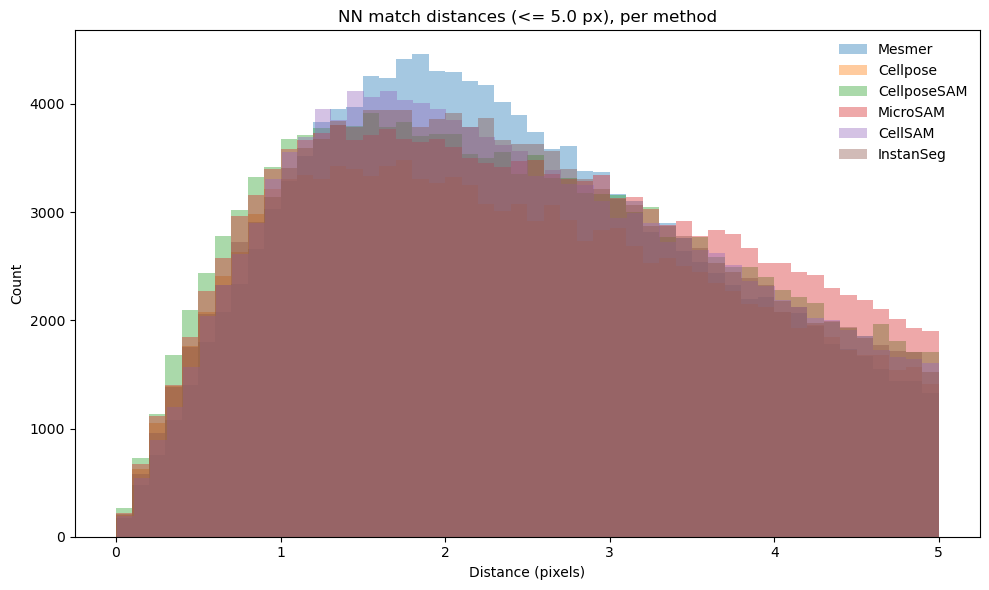

/tmp/ipykernel_295351/17681903.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


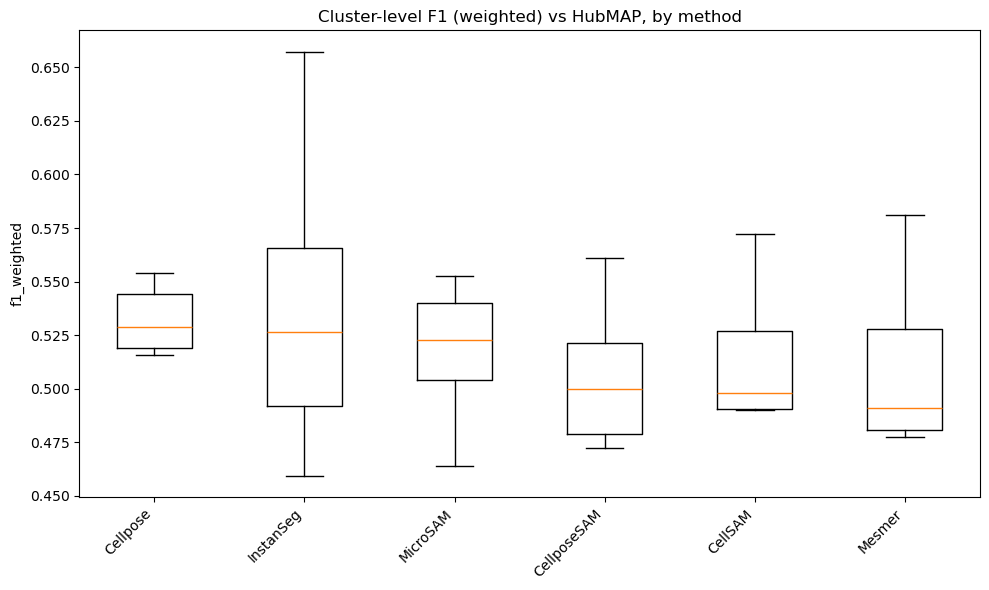

/tmp/ipykernel_295351/17681903.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


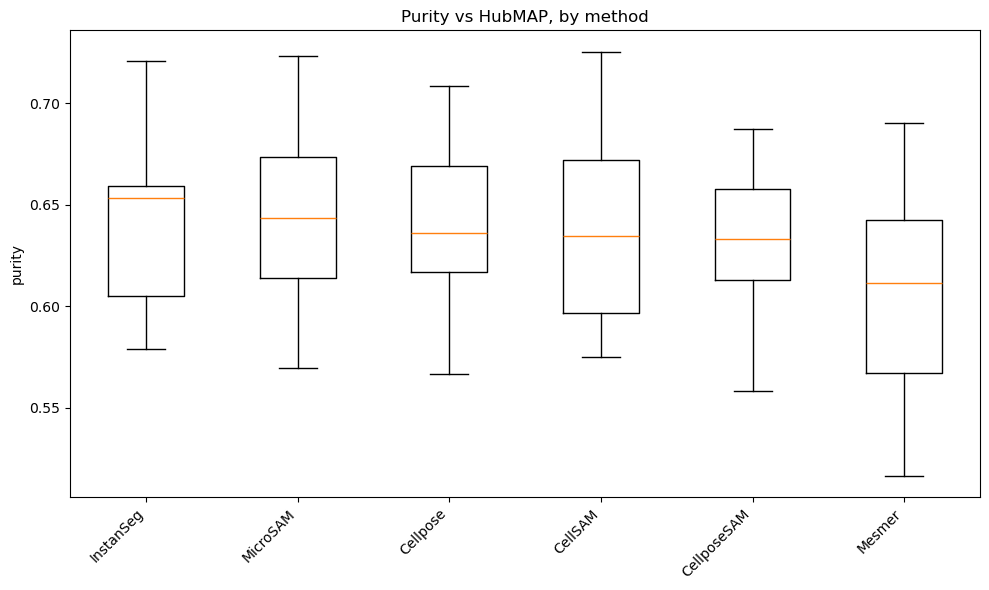

/tmp/ipykernel_295351/17681903.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


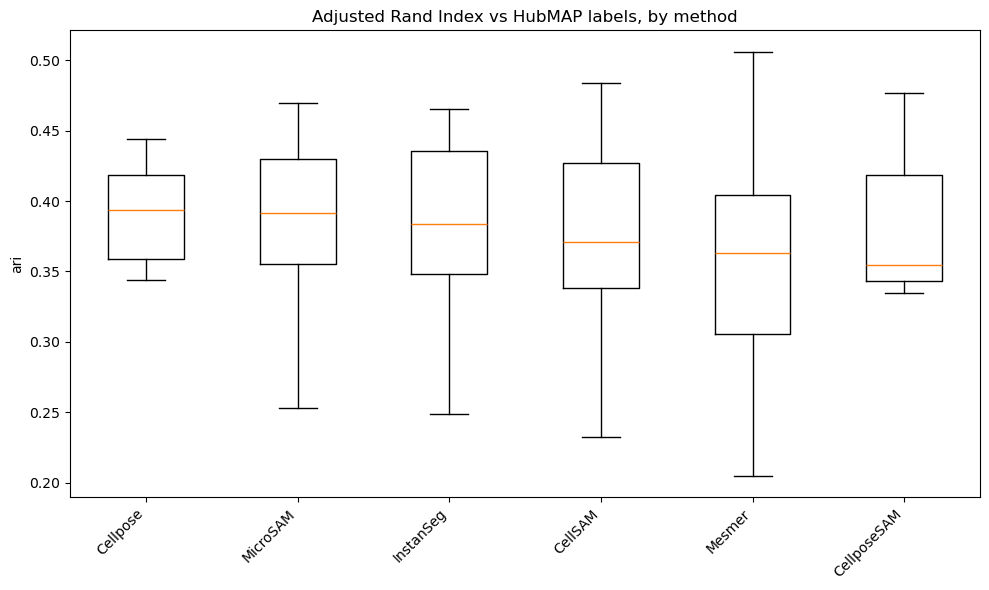

/tmp/ipykernel_295351/17681903.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


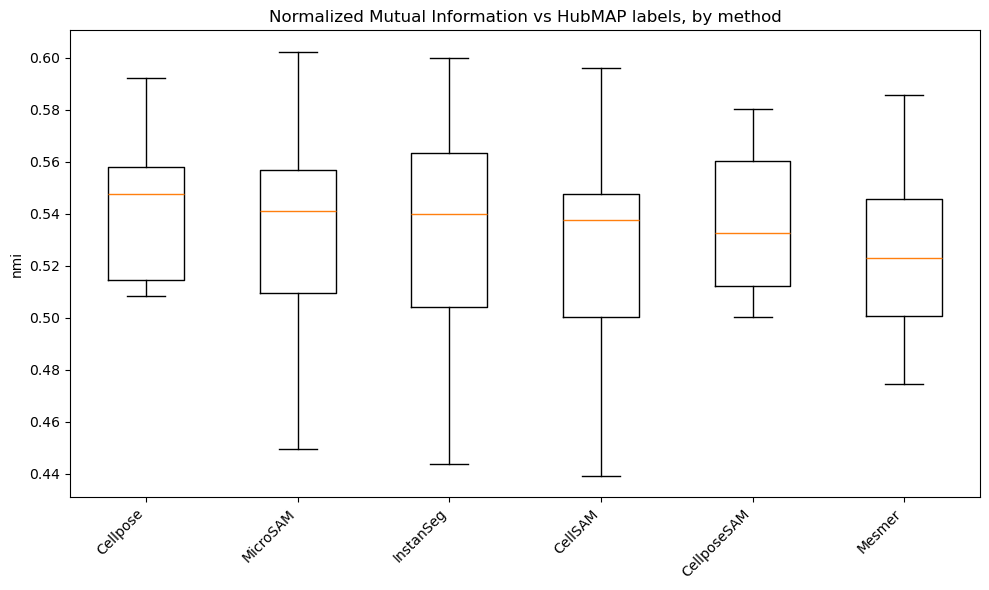

/tmp/ipykernel_295351/17681903.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


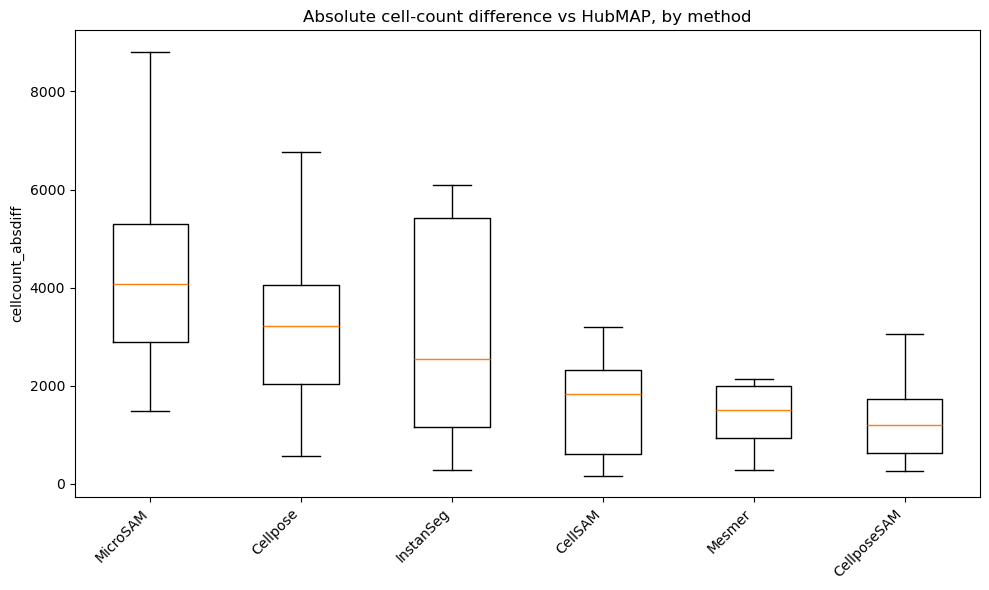

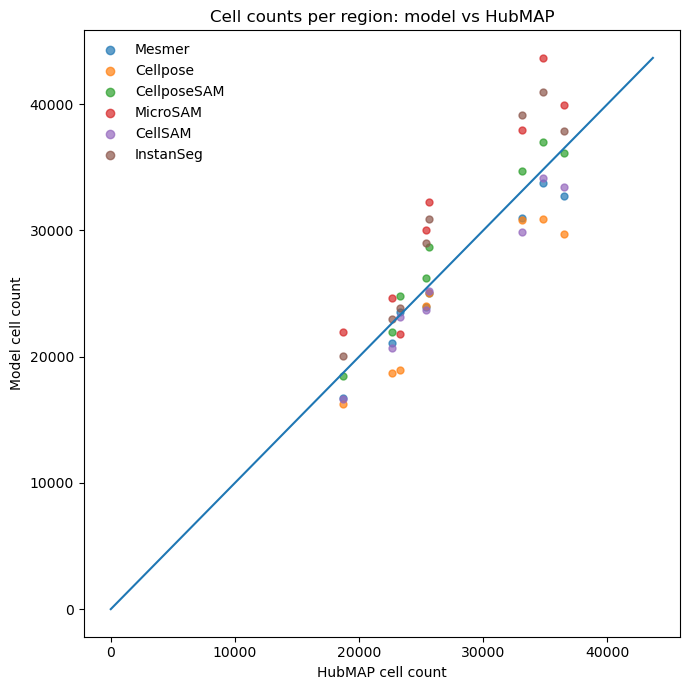

,metric,n_regions,chi2,p
5,match_rate_method,8,36.214286,8.605258e-07
1,purity,8,16.142857,6.447828e-03
0,f1_weighted,8,13.428571,1.967708e-02
4,cellcount_absdiff,8,12.714286,2.620852e-02
3,nmi,8,5.357143,3.738650e-01
2,ari,8,4.785714,4.425878e-01


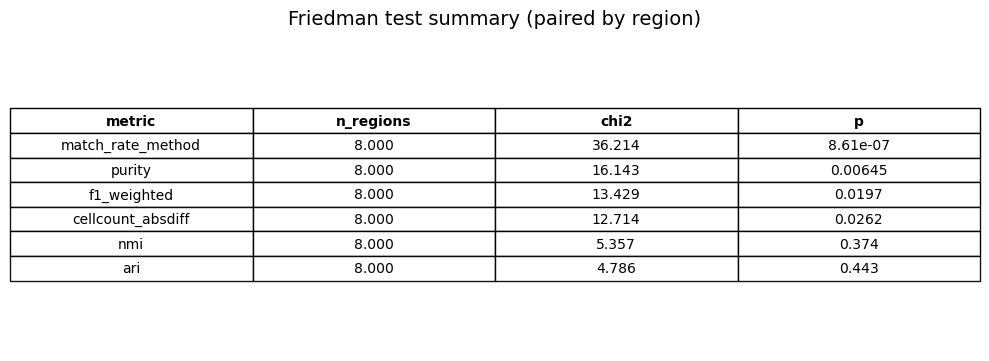

,metric,A,B,median_diff(A-B),p_value,p_adj_holm,reject_0.05
5,f1_weighted,Cellpose,CellposeSAM,0.040866,0.015625,0.234375,False
11,f1_weighted,CellposeSAM,MicroSAM,-0.031078,0.023438,0.328125,False
7,f1_weighted,Cellpose,Mesmer,0.039114,0.039062,0.507812,False
0,f1_weighted,CellSAM,Cellpose,-0.025651,0.039062,0.507812,False
9,f1_weighted,CellposeSAM,InstanSeg,-0.038957,0.039062,0.507812,False
14,f1_weighted,Mesmer,MicroSAM,-0.026970,0.078125,0.781250,False
4,f1_weighted,CellSAM,MicroSAM,-0.018483,0.109375,0.984375,False
1,f1_weighted,CellSAM,CellposeSAM,0.014250,0.109375,0.984375,False
6,f1_weighted,Cellpose,InstanSeg,0.003754,0.640625,1.000000,False
3,f1_weighted,CellSAM,Mesmer,0.008541,0.250000,1.000000,False


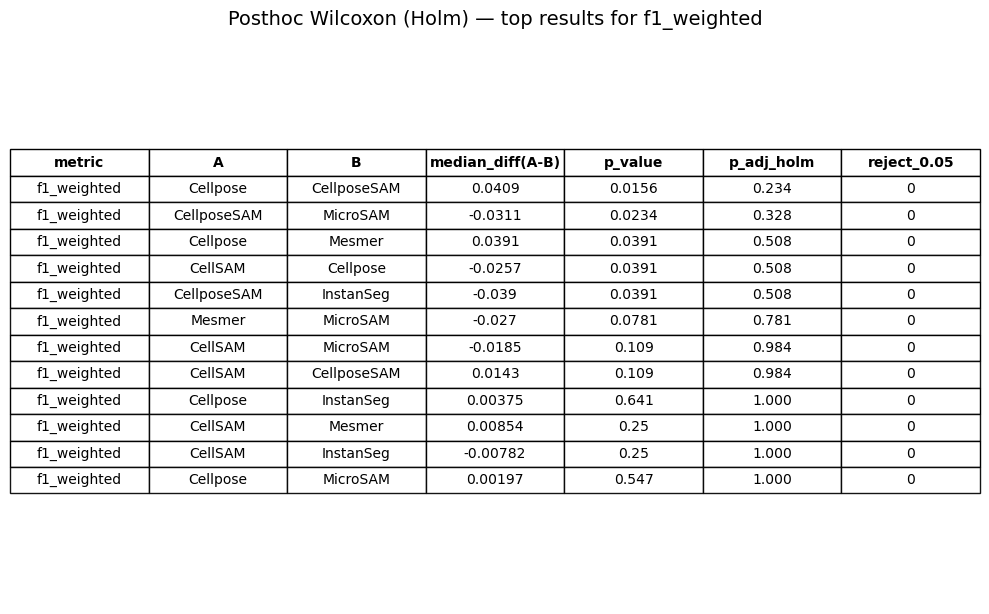

In [12]:
plt.figure(figsize=(10, 6))
for method, dists in dist_by_method.items():
    if len(dists) == 0:
        continue
    plt.hist(dists, bins=50, alpha=0.4, label=method)
plt.title(f"NN match distances (<= {MAX_DIST} px), per method")
plt.xlabel("Distance (pixels)")
plt.ylabel("Count")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# 9b) Boxplots of key metrics
def boxplot_metric(df, metric, title):
    plot_df = df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        return
    order = (plot_df.groupby("method")[metric].median().sort_values(ascending=False).index.tolist())
    data = [plot_df.loc[plot_df["method"] == m, metric].to_numpy() for m in order]
    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=order, showfliers=False)
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

boxplot_metric(metrics_df, "f1_weighted", "Cluster-level F1 (weighted) vs HubMAP, by method")
boxplot_metric(metrics_df, "purity", "Purity vs HubMAP, by method")
boxplot_metric(metrics_df, "ari", "Adjusted Rand Index vs HubMAP labels, by method")
boxplot_metric(metrics_df, "nmi", "Normalized Mutual Information vs HubMAP labels, by method")
boxplot_metric(metrics_df, "cellcount_absdiff", "Absolute cell-count difference vs HubMAP, by method")

# 9c) Cell count scatter by region (model vs HubMAP)
plt.figure(figsize=(7, 7))
for method in metrics_df["method"].unique():
    sub = metrics_df[metrics_df["method"] == method]
    plt.scatter(sub["cellcount_hubmap"], sub["cellcount_method"], s=25, alpha=0.7, label=method)
mx = max(metrics_df["cellcount_hubmap"].max(), metrics_df["cellcount_method"].max())
plt.plot([0, mx], [0, mx])
plt.title("Cell counts per region: model vs HubMAP")
plt.xlabel("HubMAP cell count")
plt.ylabel("Model cell count")
plt.legend(frameon=False, markerscale=1.2)
plt.tight_layout()
plt.show()

# 9d) Optional: Friedman summary as a clean visual table
if not friedman_df.empty:
    display(friedman_df)
    render_table_figure(friedman_df, title="Friedman test summary (paired by region)")




# 9e) Optional: show top posthoc results for one metric as a clean visual table
metric_to_show = "f1_weighted"
if metric_to_show in posthoc_tables:
    ph = posthoc_tables[metric_to_show].head(12).copy()
    display(ph)
    render_table_figure(ph, title=f"Posthoc Wilcoxon (Holm) — top results for {metric_to_show}")